# Bending PSD Analysis

Understanding the limits of the bending mode fit using PSDs. 

The goal of this notebook is to take a Von Karman PSD generated using inputs that accurately represent the mirror and generate realistic OPD maps. From these generated OPD maps, we can fit bending modes to them and calculate another PSD from this fitted map. The final PSD calculated is repesentative of the spatial frequencies we can accurately characterize with bending modes. 

In [1]:
from pathlib import Path

import numpy as np
import psd_utils
from matplotlib import pyplot as plt
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import RectBivariateSpline

from rfcml_bending import Bending
from rfcml_bending.force_matrix import ForceSpace

from matplotlib import pyplot as plt, cm
from matplotlib import colors


%matplotlib inline

## Generate PSD using psd_utils package

Generate a Von Karman PSD using the parameters listed. Output 2D slice of PSD and power map

12/12/2025 10:22:41AM - __psd_utils__ - DEBUG - normalization scale factor=4.5813e+00
DEBUG:__psd_utils__:normalization scale factor=4.5813e+00
12/12/2025 10:22:41AM - __psd_utils__ - DEBUG - 2d normalization factor is von_karman.psd_2d_rms_scale=np.float64(2.725085157421282)
DEBUG:__psd_utils__:2d normalization factor is von_karman.psd_2d_rms_scale=np.float64(2.725085157421282)


PSD now scaled to RMS.


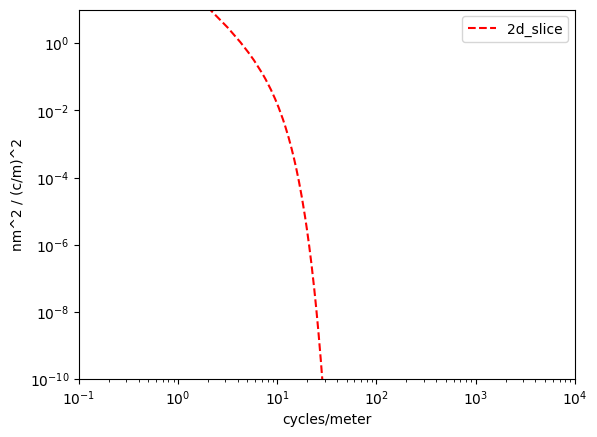

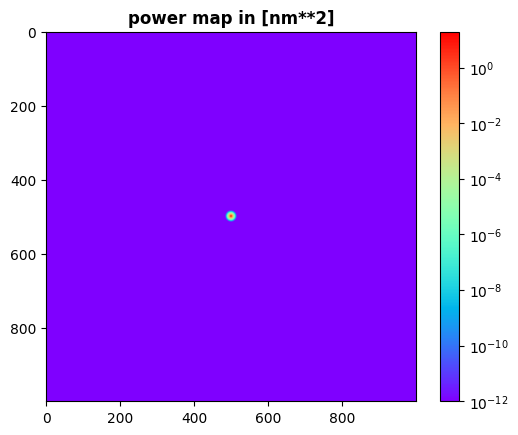

In [8]:
psd_tools = psd_utils.PSDUtils()

coords = psd_tools.coord_arrays((int(1000), int(1000)), dx=5e-4)

k = np.logspace(np.log10(0.15), np.log10(4e5), 200)  # [cycles/m]
k_min = np.min(k)
k_max = np.min(k)

psd = psd_tools.von_karman_psd(coords, 20.0, 6.5, 2.8,0.15 ,1.0e-12, rms=20, k_min=None, k_max=None, rms_scaling=True, only_1d =False) # generate PSD using von karman approach

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
x = psd.psd_1d_freqs
y = psd.psd_1d

ax.plot(x, y, label="2d_slice", color="red", linestyle="dashed")
ax.set_xlabel("cycles/meter")
ax.set_ylabel("nm^2 / (c/m)^2")

ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylim(bottom=1e-10, top=1e1)
ax.set_xlim(left=1e-1, right=1e4)

ax.legend()

plt.figure()

power = psd.psd_2d * coords.dk**2
im = plt.imshow(psd.psd_2d, cmap=cm.rainbow, norm=colors.LogNorm())
plt.title("power map in [nm**2]", fontweight="bold")
plt.colorbar(im)
plt.show()
 


## Generate OPD map from PSD

Set some defined 1000 x 1000 pupil mask and utilize the create_map method in psd_utils to create a map from some PSD. 

A seed is defined when creating a map so that multiple WFE maps can be derived from the same PSD with pseudo-random phases applied. The seed does not create a completely randomized set of phases each time the simulation is ran, but is constrained so that the results of simulation can be reproduced.

12/12/2025 10:22:46AM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 8.9863e+00
DEBUG:__psd_utils__:RMS of map at end of create_map is: 8.9863e+00
12/12/2025 10:22:46AM - __psd_utils__ - WARNING - Found zeros in map that aren't masked.


sigma is: 7.964 
RMS is: 7.964 
PTV is: 34.493 
Minimum value is: -13.518 
Maximum value is: 20.975 


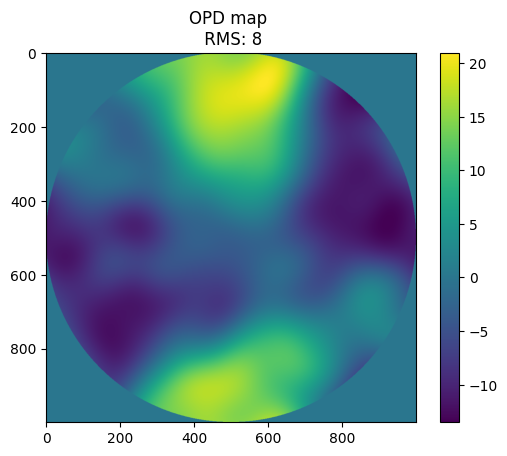

In [9]:
pupil_mask = np.zeros((int(1000), int(1000)))
pupil_mask[coords.r_grid < (0.5 / 2)] = 1
opd = psd_tools.create_map(coords, psd, mask=pupil_mask, rms=None, seed=15)
stats_ab = psd_tools.get_map_stats(opd.map, mask = np.isfinite(opd.map), report=True)

#opd.map[opd.map == 0] = np.nan

plt.figure()
plt.title(f"OPD map \n RMS: {round(stats_ab.rms)}")
plt.imshow(opd.map)
plt.colorbar()

## Fit OPD map to 33 Bending Modes

Fit OPD map produced by PSD to 33 bending modes. Need to load in a force_space file and also bending mode package.

Extract important information from forceSpace file such as semi-diameter of the mirror and x- and y- node locations in FEA space.

In [10]:
repo_root = Path.cwd()
repo = repo_root.parents[1]
path_forcespace = repo / "tests" / "data" / "stp_tel_166_forcespace_mkII.mat"
file_path = Path(path_forcespace)
force_space = ForceSpace(file_path)
b = Bending(file_path)

semi_dia = 3256.3
xlin = np.linspace(-semi_dia, semi_dia, opd.map.shape[0])
ylin = np.linspace(-semi_dia, semi_dia, opd.map.shape[1])
xc, yc = np.meshgrid(xlin, ylin)
eff_idx = ~np.isnan(opd.map)

mask = (opd.map != 0)

x_node = force_space.data["x_nodes"]
y_node = force_space.data["y_nodes"]

array_test = list(zip(x_node, y_node))
array_test = np.array(array_test)


Interpolate the map to FEA space using the x and y node locations.

In [11]:
fe_grid = RegularGridInterpolator((xlin, ylin), opd.map)
result = fe_grid(array_test)


Fit given OPD map to 33 bending modes. 

Also output the statistics of the fit map and output RMS of fit to compare with input OPD. 

Not fitting modes: [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165]
[ -0.86900498  -1.10431434  -1.47695911 ... -11.0873037  -11.20179784
 -10.93432748]
sigma is: 8.688 
RMS is: 8.689 
PTV is: 37.351 
Minimum value is: -15.630 
Maximum value is: 21.721 


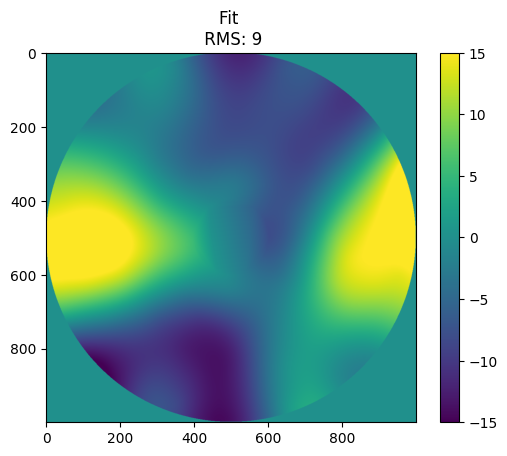

In [12]:
rmsForces_bal, b_mode_fit, forces = b.fit_bending(modes_to_fit = np.arange(0, 33), map=result)
print(b_mode_fit)
#b_mode_fit_map = force_space.fea_to_grid(b_mode_fit, coords=coords, method="linear")
b_mode_fit_map = griddata((x_node, y_node), b_mode_fit, (xc, yc))
b_mode_fit_map = b_mode_fit_map

stats_fit = psd_tools.get_map_stats(b_mode_fit_map, mask = np.isfinite(b_mode_fit_map), report=True)
b_mode_fit_map = np.nan_to_num(b_mode_fit_map, nan=0)


plt.figure()
plt.imshow(b_mode_fit_map, vmin=-15, vmax=15)
plt.title(f"Fit \n RMS: {round(stats_fit.rms)}")
plt.colorbar()

## Generate PSD from bending mode fit map

Use the bending mode fit map to generate another PSD. For now, this will save the final PSD to a .pdf file. Future iterations of this notebook should have the PSD output in its own plot.

In [7]:
meas_psd = psd_tools.measure_psd(b_mode_fit_map, coords=coords, mask=pupil_mask, max_rad=250)

psd_tools.create_plots(coords=coords, profiles=meas_psd, psd=psd, mask=pupil_mask, prefix="bending_fit_")



12/12/2025 10:22:21AM - __psd_utils__ - INFO - Using the coords array provided.
INFO:__psd_utils__:Using the coords array provided.
12/12/2025 10:22:23AM - __psd_utils__ - DEBUG - Measured total in generated profile: psd_pow1=np.float64(369.32262111255585)
DEBUG:__psd_utils__:Measured total in generated profile: psd_pow1=np.float64(369.32262111255585)
12/12/2025 10:22:23AM - __psd_utils__ - DEBUG - total theoretical profile area from integral = 791816.1097287538
DEBUG:__psd_utils__:total theoretical profile area from integral = 791816.1097287538
12/12/2025 10:22:23AM - __psd_utils__ - DEBUG - Total in theoretical profile: psd_pow2=np.float64(409.1038572545492)
DEBUG:__psd_utils__:Total in theoretical profile: psd_pow2=np.float64(409.1038572545492)
12/12/2025 10:22:23AM - __psd_utils__ - INFO - area scale is 9.028e-01
INFO:__psd_utils__:area scale is 9.028e-01
12/12/2025 10:22:23AM - __psd_utils__ - WARNING - Found zeros in map that aren't masked.
12/12/2025 10:22:23AM - __psd_utils__ -